In [ ]:
import sys
print(sys.version)
print(sys.executable)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
/usr/bin/python3


## Model creation

In [14]:
import numpy as np
import os

data =  np.load('/content/drive/MyDrive/tea leaf/data.npy', allow_pickle=True)
target = np.load('/content/drive/MyDrive/tea leaf/target.npy', allow_pickle=True)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
print(target.shape)
print(data.shape)

(5276, 7)
(5276, 128, 128, 3)


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense,
    Dropout, BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

model = Sequential()

# -----------------------------
# Block 1
# -----------------------------
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    activation='relu',
    input_shape=(128,128,3)
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# -----------------------------
# Block 2
# -----------------------------
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.30))

# -----------------------------
# Block 3
# -----------------------------
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.35))

# -----------------------------
# Block 4
# -----------------------------
model.add(Conv2D(
    filters=256,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=256,
    kernel_size=(3,3),
    padding='same',
    activation='relu'
))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.40))

# -----------------------------
# Classifier
# -----------------------------
model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(target.shape[1], activation='softmax'))

# -----------------------------
# Compile model
# -----------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,209,895 (4.62 MB)

 Trainable params: 1,207,975 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels
y_classes = np.argmax(target, axis=1)

# Stratified split
x_train, x_val, y_train, y_val = train_test_split(
    data, target,
    test_size=0.2,
    random_state=42,
    stratify=y_classes
)

print(f"Training: {x_train.shape}, Validation: {x_val.shape}")
print(f"Training classes: {y_train.sum(axis=0)}")
print(f"Validation classes: {y_val.sum(axis=0)}")

# Compute class weights (optional - try without first)
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_classes),
    y=y_train_classes
)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(np.unique(y_train_classes), class_weights)}
print(f"Class weights: {class_weight_dict}")

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_tea_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Train WITHOUT augmentation
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,  # Optional: remove if causing issues
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Training: (4220, 128, 128, 3), Validation: (1056, 128, 128, 3)
Training classes: [ 334.  405.  810.  486.  412. 1025.  748.]
Validation classes: [ 84. 101. 203. 121. 103. 257. 187.]
Class weights: {0: 1.8049615055603079, 1: 1.4885361552028218, 2: 0.7442680776014109, 3: 1.2404467960023515, 4: 1.463245492371706, 5: 0.5881533101045296, 6: 0.8059587471352178}
Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.2235 - loss: 2.1049
Epoch 1: val_accuracy improved from None to 0.11458, saving model to best_tea_model.keras

Epoch 1: finished saving model to best_tea_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 53s 211ms/step - accuracy: 0.2732 - loss: 1.8891 - val_accuracy: 0.1146 - val_loss: 2.4149 - learning_rate: 1.0000e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3636 - loss: 1.6412
Epoch 2: val_accuracy did not improve from 0.11458
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.3934 - loss: 1.5766 - val_accuracy: 0.1146 - val_loss: 3.4515 - le

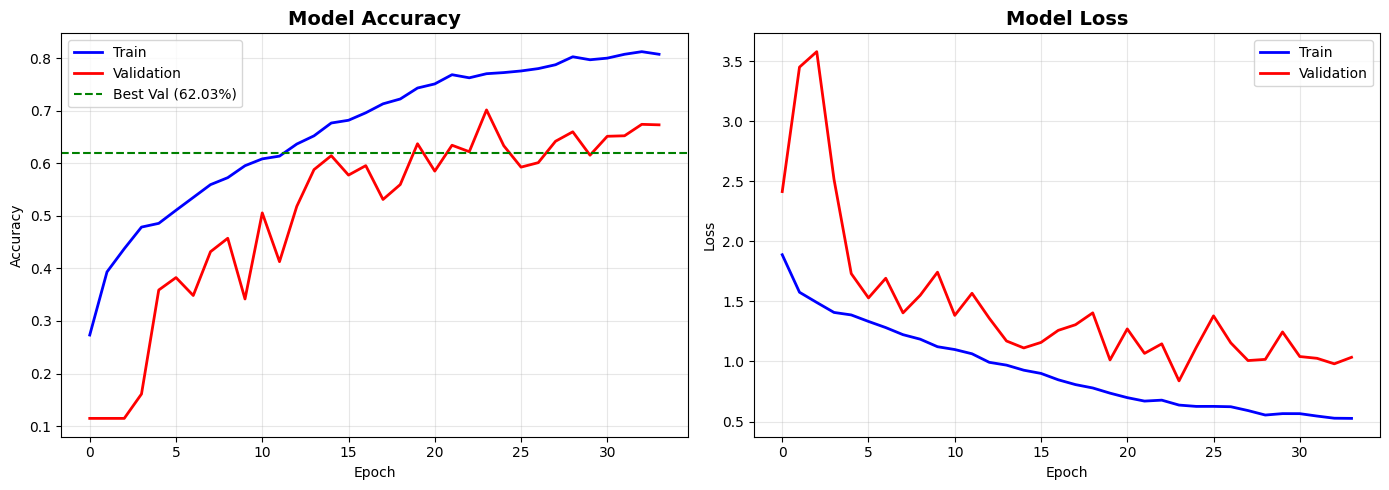


Best Validation Accuracy: 0.7017
Best Epoch: 24


In [19]:
import matplotlib.pyplot as plt

def plot_final_results(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], 'b-', label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[0].axhline(y=0.6203, color='g', linestyle='--', label='Best Val (62.03%)')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], 'b-', label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nBest Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
    print(f"Best Epoch: {np.argmax(history.history['val_accuracy'])+1}")

plot_final_results(history)

In [17]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Use pre-trained model (already knows edges, shapes, patterns)
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'  # Pre-trained on 1.4M images
)
base_model.trainable = False  # Freeze pre-trained weights

# Add your classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(7, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train (will converge faster and perform better)
history_transfer = transfer_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Expected accuracy: 75-85%!

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2252 - loss: 2.2797
Epoch 1: val_accuracy did not improve from 0.70170
132/132 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.2825 - loss: 1.9982 - val_accuracy: 0.5161 - val_loss: 1.4593 - learning_rate: 1.0000e-04
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4182 - loss: 1.6028
Epoch 2: val_accuracy did not improve from 0.70170
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4453 - loss: 1.5292 - val_accuracy: 0.5701 - val_loss: 1.2696 - learning_rate: 1.0000e-04
Epoch 3/30
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4745 - loss: 1.4385
Epoch 3: val_accuracy did not improve from 0.70170
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.4979 - loss: 1.3932 - val_accuracy: 0.6184 - val_loss: 1.1196 - learning_rate: 1.0000e-04
Epoch 4/30
128/132 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5484 - loss: 1.2822
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.9999

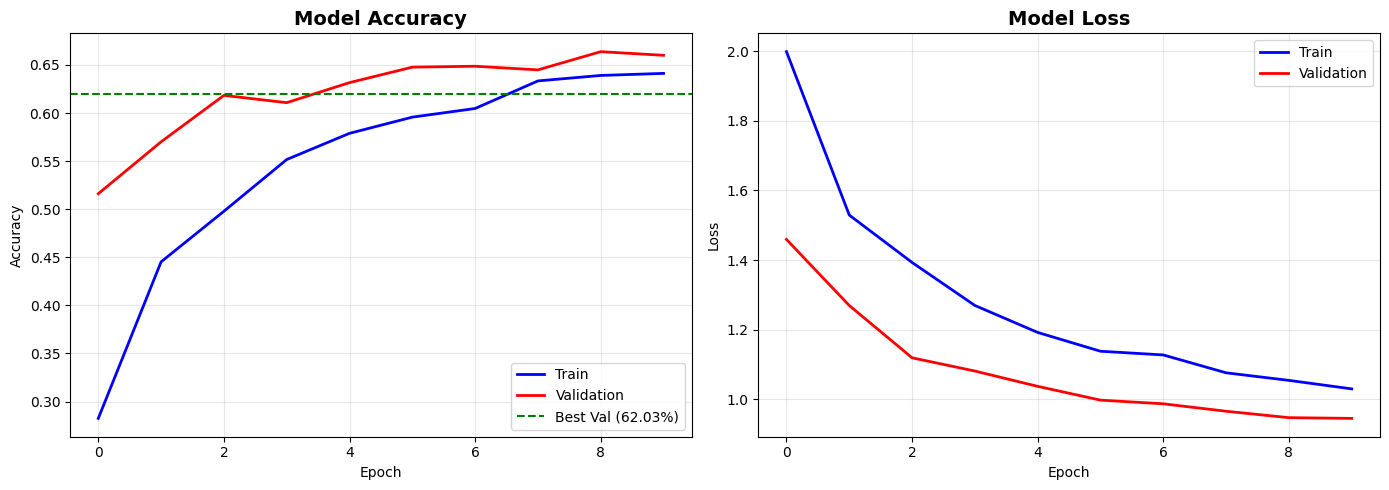


Best Validation Accuracy: 0.6638
Best Epoch: 9


In [18]:
import matplotlib.pyplot as plt

def plot_final_results(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], 'b-', label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
    axes[0].axhline(y=0.6203, color='g', linestyle='--', label='Best Val (62.03%)')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], 'b-', label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nBest Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
    print(f"Best Epoch: {np.argmax(history.history['val_accuracy'])+1}")

plot_final_results(history_transfer)

In [20]:
model.save('final_tea_model.h5')